In [1]:
!pip install git+https://github.com/CzarJoti/PRECO.git@main git+https://github.com/CzarJoti/IntroDataSci_Utils.git@main

  Cloning https://github.com/CzarJoti/PRECO.git (to revision main) to /tmp/pip-req-build-gyuichi1
  Running command git clone --filter=blob:none --quiet https://github.com/CzarJoti/PRECO.git /tmp/pip-req-build-gyuichi1
  Resolved https://github.com/CzarJoti/PRECO.git to commit fca04ee11e019da92bff4788e9009d076baf8eaa
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/CzarJoti/IntroDataSci_Utils.git (to revision main) to /tmp/pip-req-build-f_a9rdzy
  Running command git clone --filter=blob:none --quiet https://github.com/CzarJoti/IntroDataSci_Utils.git /tmp/pip-req-build-f_a9rdzy
  Resolved https://github.com/CzarJoti/IntroDataSci_Utils.git to commit b328be63a67c30465735ab948250b68ebb6a964b
  Preparing metadata (setup.py) ... done
  Created wheel for PRECO: filename=PRECO-0.1.0-py3-none-any.whl size=11960 sha256=c4fc8e8fecdfe38f278bd5b791242f8d69e0d42989caf069819d371983017c1a
  Stored in directory: /tmp/pip-ephem-wheel-cache-x9qijl1o/wheels/d6/af/18/35f8d32f6bde66dde0

In [2]:
!pip install optuna torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.5 MB/s eta 0:00:00


In [3]:
from PRECO.utils import *
import PRECO.optim as optim
from PRECO.PCN import *

import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler, random_split
from tqdm import tqdm
from torch.amp import autocast

CUDA available, using GPU


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from intro_datasci_utils.unsw import UNSW



validation = 0.1

# data_path = "./mnist/data/"

# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# mnist_train = torchvision.datasets.MNIST(root=data_path, train=True, transform=transform, download=True)
# test_set = torchvision.datasets.MNIST(root=data_path, train=False, transform=transform, download=True)

# train_idx, val_idx, _, _ = train_test_split(
#     range(len(mnist_train)),
#     mnist_train.targets,
#     stratify=mnist_train.targets,
#     test_size=validation
# )

# train_set = Subset(mnist_train, train_idx)
# val_set = Subset(mnist_train, val_idx)

set_train = UNSW("/content/drive/MyDrive/intro_datasci/unsw/UNSW_NB15_training-set.csv")
test_set = UNSW("/content/drive/MyDrive/intro_datasci/unsw/UNSW_NB15_testing-set.csv", transformer=set_train.transformer)

train_idx, val_idx, _, _ = train_test_split(
    range(len(set_train)),
    set_train.y,
    stratify=set_train.y,
    test_size=validation
)

train_set = Subset(set_train, train_idx)
val_set = Subset(set_train, val_idx)



In [6]:
batch_size = 4000

train_loader = preprocess(DataLoader(
    train_set,
    batch_size=batch_size,
    sampler=SubsetRandomSampler(list(range(len(train_set)))),
    drop_last=False,
  ))

val_loader = preprocess(DataLoader(
      val_set,
      batch_size=len(val_set),
      shuffle=False,
      drop_last=False,
  ))

test_loader = preprocess(DataLoader(
      test_set,
      batch_size=len(test_set),
      shuffle=False,
      drop_last=False,
  ))

In [27]:
from torch.nn.functional import binary_cross_entropy_with_logits
from torchmetrics import MeanMetric
import math

def optimize(trial):
  loss_metric = MeanMetric().to(DEVICE)

  hidden1_size = trial.suggest_int('hidden1_size', 64, 388)
  hidden2_size = trial.suggest_int('hidden2_size', 4, 64)
  layers = [194, hidden1_size, hidden2_size, 1]

  structure = PCN_AMB(
      layers=layers,
      f=relu,
      use_bias=True,
      upward=True,
  )

  epochs = 10

  eta_learn = trial.suggest_float('learn', 1e-5, 1e-3)

  eta_infer = 0.05

  T_infer = 50

  PCN: PCnet = PCnet(
    structure=structure,
    lr_x=eta_infer,
    T_train=T_infer,
    incremental=False,
    use_feedforward_init=True,
  )

  decay = trial.suggest_float('decay', 1e-6, 1e-3)

  opt = optim.Adam(
      PCN.params,
      learning_rate=eta_learn,
      grad_clip=1,
      batch_scale=False,
      weight_decay=decay,
  )

  PCN.set_optimizer(opt)

  with torch.no_grad():
    for epoch in range(epochs):
      for x_batch, y_batch in tqdm(train_loader):
          y_batch = y_batch.view(-1, 1)
          PCN.train_supervised(x_batch, y_batch)

  loss = 0
  for x_batch, y_batch in val_loader:
    y_true = y_batch.view(-1, 1)
    y_pred = PCN.test_supervised(x_batch)

    loss_metric.update(binary_cross_entropy_with_logits(y_pred, y_true), weight = x_batch.size()[0])

  loss = loss_metric.compute().cpu().item()

  return loss

In [28]:
import optuna

study = optuna.create_study(direction='minimize')
study.optimize(optimize, n_trials=50)
print("Best Hyperparameters:", study.best_params)

[I 2026-05-08 17:49:34,109] A new study created in memory with name: no-name-4b5322db-fa8b-4041-b152-8090e8e2bf18
100%|██████████| 40/40 [00:01<00:00, 22.89it/s]
[I 2026-05-08 17:49:51,637] Trial 0 finished with value: 0.47342079877853394 and parameters: {'hidden1_size': 365, 'hidden2_size': 45, 'learn': 0.0006383097771981269, 'decay': 0.0007177428089692589}. Best is trial 0 with value: 0.47342079877853394.
100%|██████████| 40/40 [00:01<00:00, 27.33it/s]
[I 2026-05-08 17:50:06,338] Trial 1 finished with value: 0.5232995748519897 and parameters: {'hidden1_size': 317, 'hidden2_size': 8, 'learn': 9.37564890273899e-05, 'decay': 0.0002463815512174029}. Best is trial 0 with value: 0.47342079877853394.
100%|██████████| 40/40 [00:01<00:00, 33.14it/s]
[I 2026-05-08 17:50:18,860] Trial 2 finished with value: 0.4770810008049011 and parameters: {'hidden1_size': 236, 'hidden2_size': 38, 'learn': 0.0002014839891272198, 'decay': 0.0004345138503368149}. Best is trial 0 with value: 0.47342079877853394.

Best Hyperparameters: {'hidden1_size': 305, 'hidden2_size': 42, 'learn': 0.00047577487893062044, 'decay': 0.00033736089185104666}


In [34]:
from torchmetrics.classification import BinaryAccuracy

acc_interval = 5

acc_metric = BinaryAccuracy(threshold=0.69).to(DEVICE)

acc_values = []

layers = [194, 305, 42, 1]

structure = PCN_AMB(
      layers=layers,
      f=relu,
      use_bias=True,
      upward=True,
  )

epochs = 100

eta_learn = 0.00047577487893062044

eta_infer = 0.05

T_infer = 50

PCN: PCnet = PCnet(
  structure=structure,
  lr_x=eta_infer,
  T_train=T_infer,
  incremental=False,
  use_feedforward_init=True,
)

opt = optim.Adam(
    PCN.params,
    learning_rate=eta_learn,
    grad_clip=1,
    batch_scale=False,
    weight_decay=0.00033736089185104666,
)

PCN.set_optimizer(opt)

with torch.no_grad():
  for epoch in range(epochs):
    for x_batch, y_batch in tqdm(train_loader):
        y_batch = y_batch.view(-1, 1)

        PCN.train_supervised(x_batch, y_batch)

    if epoch % acc_interval == 0:
        for x_batch, y_batch in val_loader:
            pred = torch.sigmoid(PCN.test_supervised(x_batch))
            target = y_batch.long().view(-1, 1)

            acc_metric.update(pred, target)

        acc_values.append(acc_metric.compute().cpu().item())

        acc_metric.reset()

100%|██████████| 40/40 [00:01<00:00, 26.00it/s]


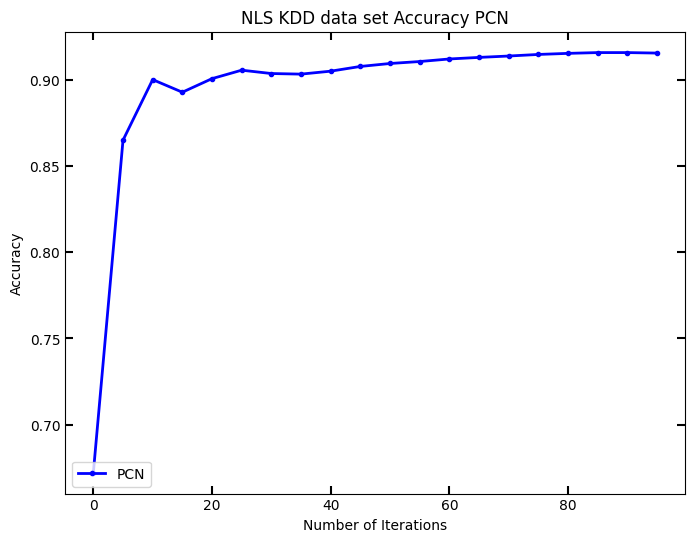

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(range(0, epochs, acc_interval), acc_values, color='b', lw=2, label='PCN',
         marker='o',
         markersize=3)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=6,
    width=1.5,
    top=True,
    right=True,
    colors='black'
)

plt.xlabel('Number of Iterations')
plt.ylabel('Accuracy')
plt.title('NLS KDD data set Accuracy PCN')
plt.legend(loc="lower left")

plt.show()

f1 value: 0.8575766682624817


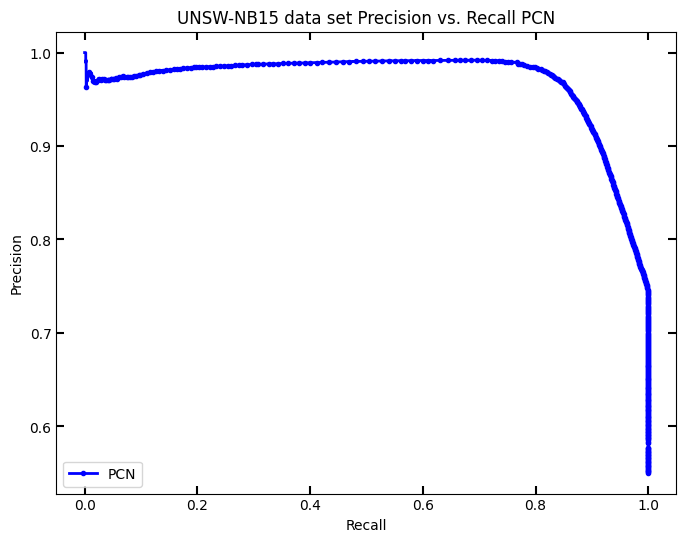

In [36]:
from torchmetrics.classification import BinaryPrecisionRecallCurve, BinaryF1Score
import matplotlib.pyplot as plt

pr_curve = BinaryPrecisionRecallCurve().to(DEVICE)

f1_metric = BinaryF1Score(threshold=0.6).to(DEVICE)

for x_batch, y_batch in test_loader:
    pred = torch.sigmoid(PCN.test_supervised(x_batch))
    target = y_batch.long().view(-1, 1)

    pr_curve.update(pred, target)
    f1_metric.update(pred, target)

precision, recall, thresholds = pr_curve.compute()
f1_res = f1_metric.compute()

print(f"f1 value: {f1_res}")

plt.figure(figsize=(8, 6))
plt.plot(recall.cpu().numpy(), precision.cpu().numpy(), color='b', lw=2, label='PCN',
         marker='o',
         markersize=3,
         markevery=100)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=6,
    width=1.5,
    top=True,
    right=True,
    colors='black'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('UNSW-NB15 data set Precision vs. Recall PCN')
plt.legend(loc="lower left")

plt.show()


Best F1: 0.910063624382019
Best Threshold: 0.7004396319389343


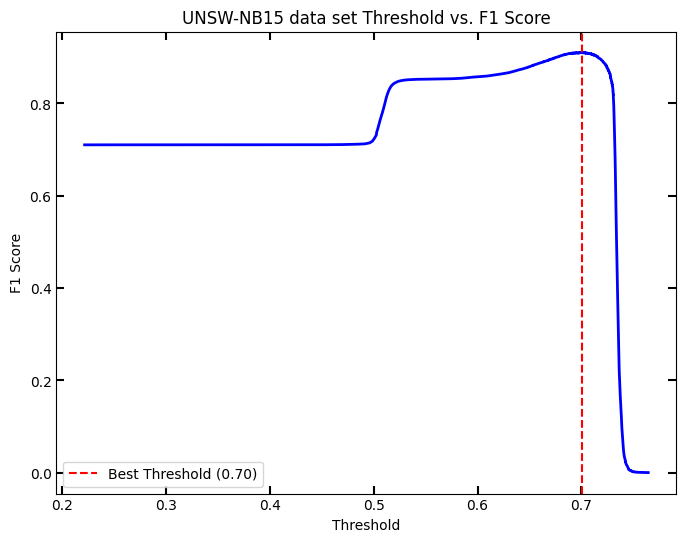

In [37]:
f1_scores = (2 * precision * recall) / (precision + recall + 1e-6)

f1_idx = torch.argmax(f1_scores)

best_f1 = f1_scores[f1_idx].item()
best_threshold = thresholds[f1_idx].item()

print(f"Best F1: {best_f1}")
print(f"Best Threshold: {best_threshold}")

plt.figure(figsize=(8, 6))
plt.plot(thresholds.cpu().numpy(), f1_scores.cpu().numpy()[:-1], color='b', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=6,
    width=1.5,
    top=True,
    right=True,
    colors='black'
)

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('UNSW-NB15 data set Threshold vs. F1 Score')
plt.legend(loc="lower left")

plt.show()

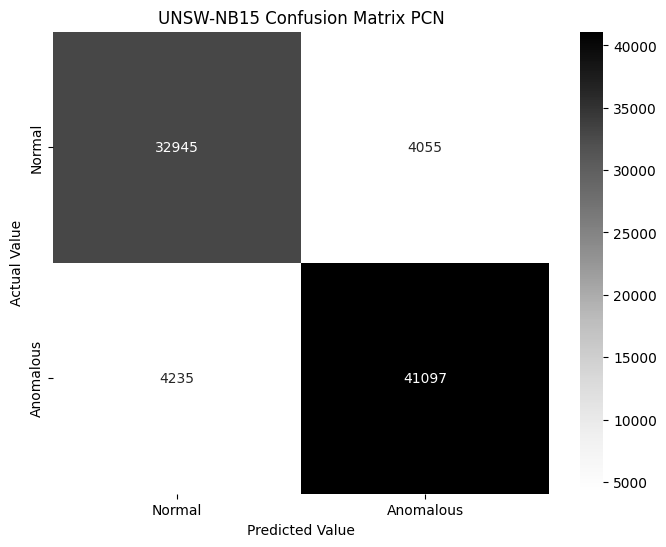

In [ ]:
from torchmetrics.classification import BinaryConfusionMatrix
from seaborn import heatmap

c_matrix = BinaryConfusionMatrix(threshold=0.70).to(DEVICE)

for x_batch, y_batch in test_loader:
    pred = torch.sigmoid(PCN.test_supervised(x_batch))
    target = y_batch.long().view(-1, 1)

    c_matrix.update(pred, target)

conf = c_matrix.compute().cpu().numpy()
labels = ["Normal", "Anomalous"]

plt.figure(figsize=(8, 6))
heatmap(conf,
    annot=True,
    fmt='g',
    cmap='Greys',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('UNSW-NB15 Confusion Matrix PCN')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')

plt.show()